#04_iv_2sls_causal_model

## Retail Pricing and Promotion Optimization

This notebook uses instrumental variables and two-stage least squares to estimate the effect of selling price on demand.

### Objectives

- Explain the price-endogeneity problem
- Prepare the instrumental-variable modelling sample
- Evaluate supplier and shipping cost indices as instruments
- Estimate the first-stage price equation
- Compare ordinary least squares with IV/2SLS
- Review instrument strength and specification diagnostics
- Compare estimated elasticity with the known synthetic benchmark
- Save model results for later optimization

### Identification strategy

Selling price may be correlated with unobserved demand conditions. For example, retailers may increase prices when they anticipate stronger demand.

The synthetic dataset therefore contains:

- an unobserved demand shock that affects price and demand;
- supplier and shipping cost indices that affect selling price;
- no direct cost-index effect in the demand equation.

The cost indices are used as excluded instruments for selling price.

> A causal interpretation requires both instrument relevance and instrument validity. Statistical diagnostics can assess relevance and detect some specification problems, but they cannot prove the exclusion restriction in real business data.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from linearmodels.iv import IV2SLS


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\marja\OneDrive\Desktop\GitHub\retail-pricing-promotion-optimization


In [2]:
from src.data.io import load_synthetic_retail_data


retail = load_synthetic_retail_data()
retail["date"] = pd.to_datetime(retail["date"])

print(f"Dataset shape: {retail.shape}")
print(
    f"Date range: {retail['date'].min().date()} "
    f"to {retail['date'].max().date()}"
)

retail.head()

Dataset shape: (18300, 29)
Date range: 2024-01-01 to 2024-12-31


,date,store_id,region,product_id,category,year,month,day_of_week,weekend_flag,holiday_flag,regular_price,selling_price,competitor_price,unit_cost,discount_pct,promotion_flag,promotion_type,promotion_propensity,advertising_spend,supplier_cost_index,shipping_cost_index,weather_index,customer_traffic,inventory_level,stockout_flag,units_sold,revenue,gross_profit,true_price_elasticity
0,2024-01-01,S001,West,P001,Beverages,2024,1,Monday,0,1,4.2900,4.2900,4.2800,2.1200,0.0000,0,none,0.2300,17.8700,1.0024,1.0188,0.5661,1206,71,0,47,201.8300,102.4100,-1.8000
1,2024-01-01,S001,West,P002,Beverages,2024,1,Monday,0,1,7.1600,7.1600,6.9300,3.2200,0.0000,0,none,0.2300,20.9500,1.0024,1.0188,0.5661,1206,52,0,50,357.9900,196.8100,-2.1000
2,2024-01-01,S001,West,P003,Beverages,2024,1,Monday,0,1,9.8400,9.8400,9.7900,4.6300,0.0000,0,none,0.2300,22.2600,1.0024,1.0188,0.5661,1206,55,0,26,255.7300,135.2600,-2.4000
3,2024-01-01,S001,West,P004,Grocery,2024,1,Monday,0,1,4.2000,4.2000,4.0800,1.7600,0.0000,0,none,0.2000,22.9300,1.0024,1.0188,0.5661,1206,120,0,91,382.6200,222.2000,-1.4000
4,2024-01-01,S001,West,P005,Grocery,2024,1,Monday,0,1,5.4900,5.4900,5.7400,2.5700,0.0000,0,none,0.2000,12.6800,1.0024,1.0188,0.5661,1206,54,1,54,296.5400,157.8300,-1.7000


In [3]:
iv_data = retail.loc[
    (retail["units_sold"] > 0)
    & (retail["selling_price"] > 0)
    & (retail["supplier_cost_index"] > 0)
    & (retail["shipping_cost_index"] > 0)
    & (retail["stockout_flag"] == 0)
].copy()

iv_data["log_units_sold"] = np.log(
    iv_data["units_sold"]
)

iv_data["log_selling_price"] = np.log(
    iv_data["selling_price"]
)

iv_data["log_supplier_cost_index"] = np.log(
    iv_data["supplier_cost_index"]
)

iv_data["log_shipping_cost_index"] = np.log(
    iv_data["shipping_cost_index"]
)

iv_data["log_customer_traffic"] = np.log(
    iv_data["customer_traffic"]
)

iv_data["log_advertising_spend"] = np.log1p(
    iv_data["advertising_spend"]
)

# Each date is treated as a cluster because the cost instruments
# are shared across many store-product observations on the same day.
iv_data["date_cluster"] = (
    iv_data["date"]
    .astype("category")
    .cat.codes
)

sample_summary = pd.Series(
    {
        "Original observations": len(retail),
        "IV observations": len(iv_data),
        "Excluded observations": len(retail) - len(iv_data),
        "Products": iv_data["product_id"].nunique(),
        "Stores": iv_data["store_id"].nunique(),
        "Date clusters": iv_data["date"].nunique(),
        "Average true elasticity": (
            iv_data["true_price_elasticity"].mean()
        ),
    },
    name="Value",
)

sample_summary.to_frame()

,Value
Original observations,"18,300.0000"
IV observations,"14,272.0000"
Excluded observations,"4,028.0000"
Products,10.0000
Stores,5.0000
Date clusters,366.0000
Average true elasticity,-1.6992


In [4]:
instrument_correlations = iv_data[
    [
        "log_selling_price",
        "log_supplier_cost_index",
        "log_shipping_cost_index",
    ]
].corr()

instrument_correlations

,log_selling_price,log_supplier_cost_index,log_shipping_cost_index
log_selling_price,1.0000,0.0583,0.0300
log_supplier_cost_index,0.0583,1.0000,0.0007
log_shipping_cost_index,0.0300,0.0007,1.0000


In [5]:
daily_instrument_data = (
    iv_data.groupby("date", as_index=False)
    .agg(
        average_selling_price=("selling_price", "mean"),
        supplier_cost_index=(
            "supplier_cost_index",
            "first",
        ),
        shipping_cost_index=(
            "shipping_cost_index",
            "first",
        ),
    )
    .sort_values("date")
)

for column in [
    "average_selling_price",
    "supplier_cost_index",
    "shipping_cost_index",
]:
    daily_instrument_data[f"{column}_indexed"] = (
        daily_instrument_data[column]
        / daily_instrument_data[column].iloc[0]
        * 100
    )

daily_instrument_data.head()

,date,average_selling_price,supplier_cost_index,shipping_cost_index,average_selling_price_indexed,supplier_cost_index_indexed,shipping_cost_index_indexed
0,2024-01-01,7.2888,1.0024,1.0188,100.0000,100.0000,100.0000
1,2024-01-02,7.5839,1.0083,1.0353,104.0486,100.5886,101.6196
2,2024-01-03,7.8232,1.0039,1.0264,107.3314,100.1496,100.7460
3,2024-01-04,7.4776,0.9884,1.0260,102.5908,98.6034,100.7067
4,2024-01-05,7.6142,1.0056,1.0154,104.4646,100.3192,99.6663


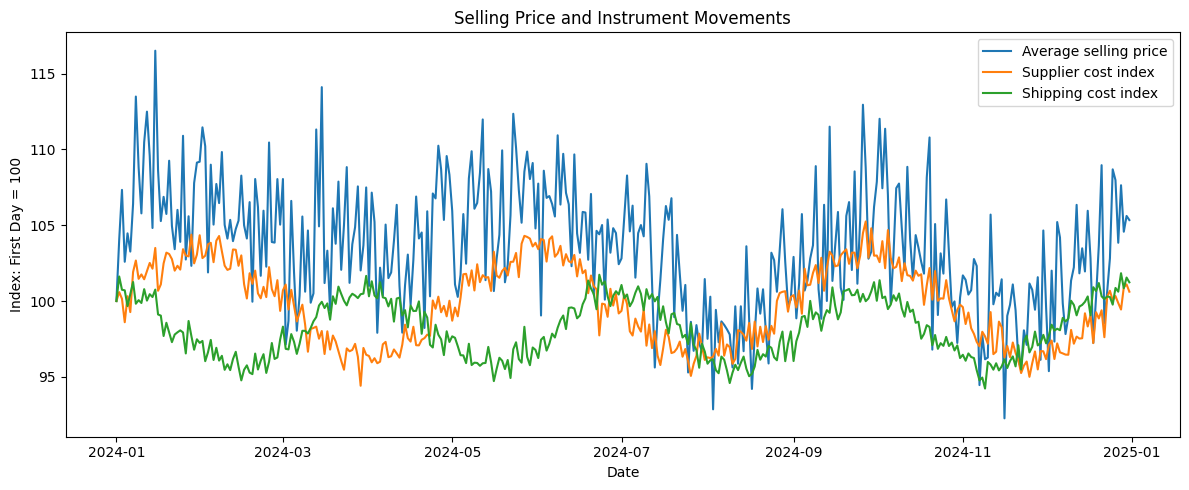

In [6]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_instrument_data["date"],
    daily_instrument_data[
        "average_selling_price_indexed"
    ],
    label="Average selling price",
)

plt.plot(
    daily_instrument_data["date"],
    daily_instrument_data[
        "supplier_cost_index_indexed"
    ],
    label="Supplier cost index",
)

plt.plot(
    daily_instrument_data["date"],
    daily_instrument_data[
        "shipping_cost_index_indexed"
    ],
    label="Shipping cost index",
)

plt.title("Selling Price and Instrument Movements")
plt.xlabel("Date")
plt.ylabel("Index: First Day = 100")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "price_and_cost_instruments.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [7]:
control_formula = """
1
+ log_customer_traffic
+ log_advertising_spend
+ weekend_flag
+ holiday_flag
+ weather_index
+ C(promotion_type)
+ C(product_id)
+ C(store_id)
+ C(month)
"""

In [8]:
ols_formula = f"""
log_units_sold
~ {control_formula}
+ log_selling_price
"""

ols_model = IV2SLS.from_formula(
    formula=ols_formula,
    data=iv_data,
)

ols_results = ols_model.fit(
    cov_type="clustered",
    clusters=iv_data["date_cluster"],
)

print("OLS model estimated successfully.")

OLS model estimated successfully.


In [9]:
ols_price_result = pd.Series(
    {
        "elasticity_estimate": (
            ols_results.params["log_selling_price"]
        ),
        "standard_error": (
            ols_results.std_errors[
                "log_selling_price"
            ]
        ),
        "p_value": (
            ols_results.pvalues[
                "log_selling_price"
            ]
        ),
        "confidence_lower": (
            ols_results.conf_int()
            .loc["log_selling_price", "lower"]
        ),
        "confidence_upper": (
            ols_results.conf_int()
            .loc["log_selling_price", "upper"]
        ),
        "r_squared": ols_results.rsquared,
        "observations": int(ols_results.nobs),
    },
    name="OLS",
)

ols_price_result.to_frame()

,OLS
elasticity_estimate,1.5531
standard_error,0.0799
p_value,0.0000
confidence_lower,1.3965
confidence_upper,1.7097
r_squared,0.8009
observations,"14,272.0000"


In [10]:
iv_formula = f"""
log_units_sold
~ {control_formula}
+ [
    log_selling_price
    ~ log_supplier_cost_index
    + log_shipping_cost_index
]
"""

iv_model = IV2SLS.from_formula(
    formula=iv_formula,
    data=iv_data,
)

iv_results = iv_model.fit(
    cov_type="clustered",
    clusters=iv_data["date_cluster"],
)

print("IV/2SLS model estimated successfully.")

IV/2SLS model estimated successfully.


In [11]:
first_stage_diagnostics = (
    iv_results.first_stage.diagnostics
    .reset_index()
    .rename(columns={"index": "endogenous_variable"})
)

first_stage_diagnostics

,endogenous_variable,rsquared,partial.rsquared,shea.rsquared,f.stat,f.pval,f.dist
0,log_selling_price,0.9925,0.1415,0.1415,"1,773.8442",0.0000,chi2(2)


In [12]:
first_stage_summary = (
    first_stage_diagnostics[
        [
            "endogenous_variable",
            "rsquared",
            "partial.rsquared",
            "shea.rsquared",
            "f.stat",
            "f.pval",
            "f.dist",
        ]
    ]
    .copy()
)

first_stage_summary

,endogenous_variable,rsquared,partial.rsquared,shea.rsquared,f.stat,f.pval,f.dist
0,log_selling_price,0.9925,0.1415,0.1415,"1,773.8442",0.0000,chi2(2)


In [13]:
first_stage_summary = (
    first_stage_diagnostics[
        [
            "endogenous_variable",
            "rsquared",
            "partial.rsquared",
            "shea.rsquared",
            "f.stat",
            "f.pval",
            "f.dist",
        ]
    ]
    .copy()
)

first_stage_summary

,endogenous_variable,rsquared,partial.rsquared,shea.rsquared,f.stat,f.pval,f.dist
0,log_selling_price,0.9925,0.1415,0.1415,"1,773.8442",0.0000,chi2(2)


In [14]:
true_average_elasticity = (
    iv_data["true_price_elasticity"].mean()
)

model_comparison = pd.DataFrame(
    {
        "model": [
            "OLS",
            "IV/2SLS",
            "Synthetic benchmark",
        ],
        "elasticity_estimate": [
            ols_results.params[
                "log_selling_price"
            ],
            iv_results.params[
                "log_selling_price"
            ],
            true_average_elasticity,
        ],
        "standard_error": [
            ols_results.std_errors[
                "log_selling_price"
            ],
            iv_results.std_errors[
                "log_selling_price"
            ],
            np.nan,
        ],
        "p_value": [
            ols_results.pvalues[
                "log_selling_price"
            ],
            iv_results.pvalues[
                "log_selling_price"
            ],
            np.nan,
        ],
        "absolute_error_from_benchmark": [
            abs(
                ols_results.params[
                    "log_selling_price"
                ]
                - true_average_elasticity
            ),
            abs(
                iv_results.params[
                    "log_selling_price"
                ]
                - true_average_elasticity
            ),
            0.0,
        ],
    }
)

model_comparison

,model,elasticity_estimate,standard_error,p_value,absolute_error_from_benchmark
0,OLS,1.5531,0.0799,0.0000,3.2523
1,IV/2SLS,-1.6298,0.1755,0.0000,0.0694
2,Synthetic benchmark,-1.6992,NaN,NaN,0.0000


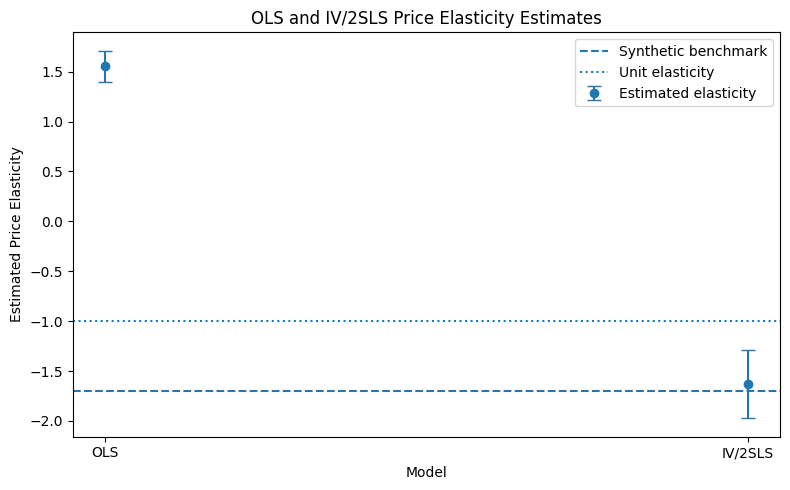

In [15]:
comparison_plot = model_comparison.loc[
    model_comparison["model"].isin(
        ["OLS", "IV/2SLS"]
    )
].copy()

x_positions = np.arange(
    len(comparison_plot)
)

plt.figure(figsize=(8, 5))

plt.errorbar(
    x_positions,
    comparison_plot["elasticity_estimate"],
    yerr=1.96
    * comparison_plot["standard_error"],
    fmt="o",
    capsize=5,
    label="Estimated elasticity",
)

plt.axhline(
    true_average_elasticity,
    linestyle="--",
    label="Synthetic benchmark",
)

plt.axhline(
    -1,
    linestyle=":",
    label="Unit elasticity",
)

plt.xticks(
    x_positions,
    comparison_plot["model"],
)

plt.title("OLS and IV/2SLS Price Elasticity Estimates")
plt.xlabel("Model")
plt.ylabel("Estimated Price Elasticity")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "ols_vs_iv_elasticity.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [16]:
wu_hausman_test = iv_results.wu_hausman(
    variables=["log_selling_price"]
)

wu_hausman_summary = pd.Series(
    {
        "test": "Wu-Hausman endogeneity test",
        "statistic": wu_hausman_test.stat,
        "p_value": wu_hausman_test.pval,
        "distribution": str(
            wu_hausman_test.dist_name
        ),
        "null_hypothesis": (
            "Selling price is exogenous"
        ),
    },
    name="Result",
)

wu_hausman_summary.to_frame()

,Result
test,Wu-Hausman endogeneity test
statistic,524.3915
p_value,0.0000
distribution,"F(1,14237)"
null_hypothesis,Selling price is exogenous


In [17]:
if wu_hausman_test.pval < 0.05:
    print(
        "Reject the null hypothesis: the evidence "
        "supports treating selling price as endogenous."
    )
else:
    print(
        "Do not reject the null hypothesis: the test "
        "does not provide strong evidence of endogeneity."
    )

Reject the null hypothesis: the evidence supports treating selling price as endogenous.


In [18]:
overid_test = iv_results.wooldridge_overid

overid_summary = pd.Series(
    {
        "test": (
            "Wooldridge overidentification test"
        ),
        "statistic": overid_test.stat,
        "p_value": overid_test.pval,
        "distribution": str(
            overid_test.dist_name
        ),
        "null_hypothesis": (
            "The overidentifying restrictions are valid"
        ),
    },
    name="Result",
)

overid_summary.to_frame()

,Result
test,Wooldridge overidentification test
statistic,0.0048
p_value,0.9445
distribution,chi2(1)
null_hypothesis,The overidentifying restrictions are valid


In [19]:
if overid_test.pval < 0.05:
    print(
        "Reject the overidentification null. "
        "The instruments may not all satisfy the "
        "model's validity assumptions."
    )
else:
    print(
        "Do not reject the overidentification null. "
        "The diagnostic does not identify a conflict "
        "with the instrument-validity assumptions."
    )

Do not reject the overidentification null. The diagnostic does not identify a conflict with the instrument-validity assumptions.


In [20]:
diagnostic_summary = pd.DataFrame(
    [
        {
            "diagnostic": (
                "First-stage relevance statistic"
            ),
            "statistic": first_stage_summary.loc[
                0, "f.stat"
            ],
            "p_value": first_stage_summary.loc[
                0, "f.pval"
            ],
            "interpretation": (
                "Tests joint relevance of excluded "
                "instruments"
            ),
        },
        {
            "diagnostic": "Wu-Hausman",
            "statistic": wu_hausman_test.stat,
            "p_value": wu_hausman_test.pval,
            "interpretation": (
                "Tests whether price can be treated "
                "as exogenous"
            ),
        },
        {
            "diagnostic": (
                "Wooldridge overidentification"
            ),
            "statistic": overid_test.stat,
            "p_value": overid_test.pval,
            "interpretation": (
                "Tests the overidentifying restriction"
            ),
        },
    ]
)

diagnostic_summary

,diagnostic,statistic,p_value,interpretation
0,First-stage relevance statistic,"1,773.8442",0.0000,Tests joint relevance of excluded instruments
1,Wu-Hausman,524.3915,0.0000,Tests whether price can be treated as exogenous
2,Wooldridge overidentification,0.0048,0.9445,Tests the overidentifying restriction


In [21]:
model_comparison_path = (
    PROCESSED_DATA_DIR
    / "iv_2sls_model_comparison.csv"
)

first_stage_path = (
    PROCESSED_DATA_DIR
    / "iv_first_stage_diagnostics.csv"
)

diagnostics_path = (
    PROCESSED_DATA_DIR
    / "iv_specification_diagnostics.csv"
)

model_comparison.to_csv(
    model_comparison_path,
    index=False,
)

first_stage_summary.to_csv(
    first_stage_path,
    index=False,
)

diagnostic_summary.to_csv(
    diagnostics_path,
    index=False,
)

print(f"Saved: {model_comparison_path}")
print(f"Saved: {first_stage_path}")
print(f"Saved: {diagnostics_path}")

Saved: c:\Users\marja\OneDrive\Desktop\GitHub\retail-pricing-promotion-optimization\data\processed\iv_2sls_model_comparison.csv
Saved: c:\Users\marja\OneDrive\Desktop\GitHub\retail-pricing-promotion-optimization\data\processed\iv_first_stage_diagnostics.csv
Saved: c:\Users\marja\OneDrive\Desktop\GitHub\retail-pricing-promotion-optimization\data\processed\iv_specification_diagnostics.csv


## Key Findings

- Ordinary least squares treats selling price as independent of unobserved demand conditions.
- The synthetic data intentionally creates price endogeneity by allowing an unobserved demand shock to influence both price and demand.
- Supplier and shipping cost indices are used as excluded instruments for selling price.
- First-stage diagnostics assess whether these instruments explain meaningful price variation after controlling for observed demand factors.
- The IV/2SLS estimate uses only the price variation explained by the excluded instruments.
- The Wu–Hausman test evaluates whether treating selling price as endogenous materially changes the model.
- The overidentification test assesses whether the two instruments appear mutually consistent with the model assumptions.
- The IV estimate can be compared with both the OLS estimate and the known synthetic elasticity benchmark.
- Instrument validity depends on business and economic reasoning, not only statistical tests.
- The estimated causal elasticity will later support price and profit optimization.